Products: <ArrowStringArray>
[                    'PEBBLES_L',           'SNACKPACK_RASPBERRY',
                  'UV_VISOR_RED',                     'PEBBLES_M',
     'GALAXY_SOUNDS_DARK_MATTER',               'UV_VISOR_ORANGE',
                     'PEBBLES_S',               'UV_VISOR_YELLOW',
            'MICROCHIP_TRIANGLE',              'MICROCHIP_SQUARE',
             'SNACKPACK_VANILLA',           'SNACKPACK_CHOCOLATE',
     'GALAXY_SOUNDS_BLACK_HOLES',                'UV_VISOR_AMBER',
              'UV_VISOR_MAGENTA',      'TRANSLATOR_GRAPHITE_MIST',
          'TRANSLATOR_VOID_BLUE',              'SLEEP_POD_COTTON',
        'OXYGEN_SHAKE_CHOCOLATE',                     'PANEL_1X2',
                     'PANEL_1X4',    'GALAXY_SOUNDS_SOLAR_FLAMES',
                  'ROBOT_DISHES',           'MICROCHIP_RECTANGLE',
     'GALAXY_SOUNDS_SOLAR_WINDS',           'SLEEP_POD_POLYESTER',
               'ROBOT_VACUUMING',           'SNACKPACK_PISTACHIO',
 'GALAXY_SOUNDS_PLANETARY_RINGS',

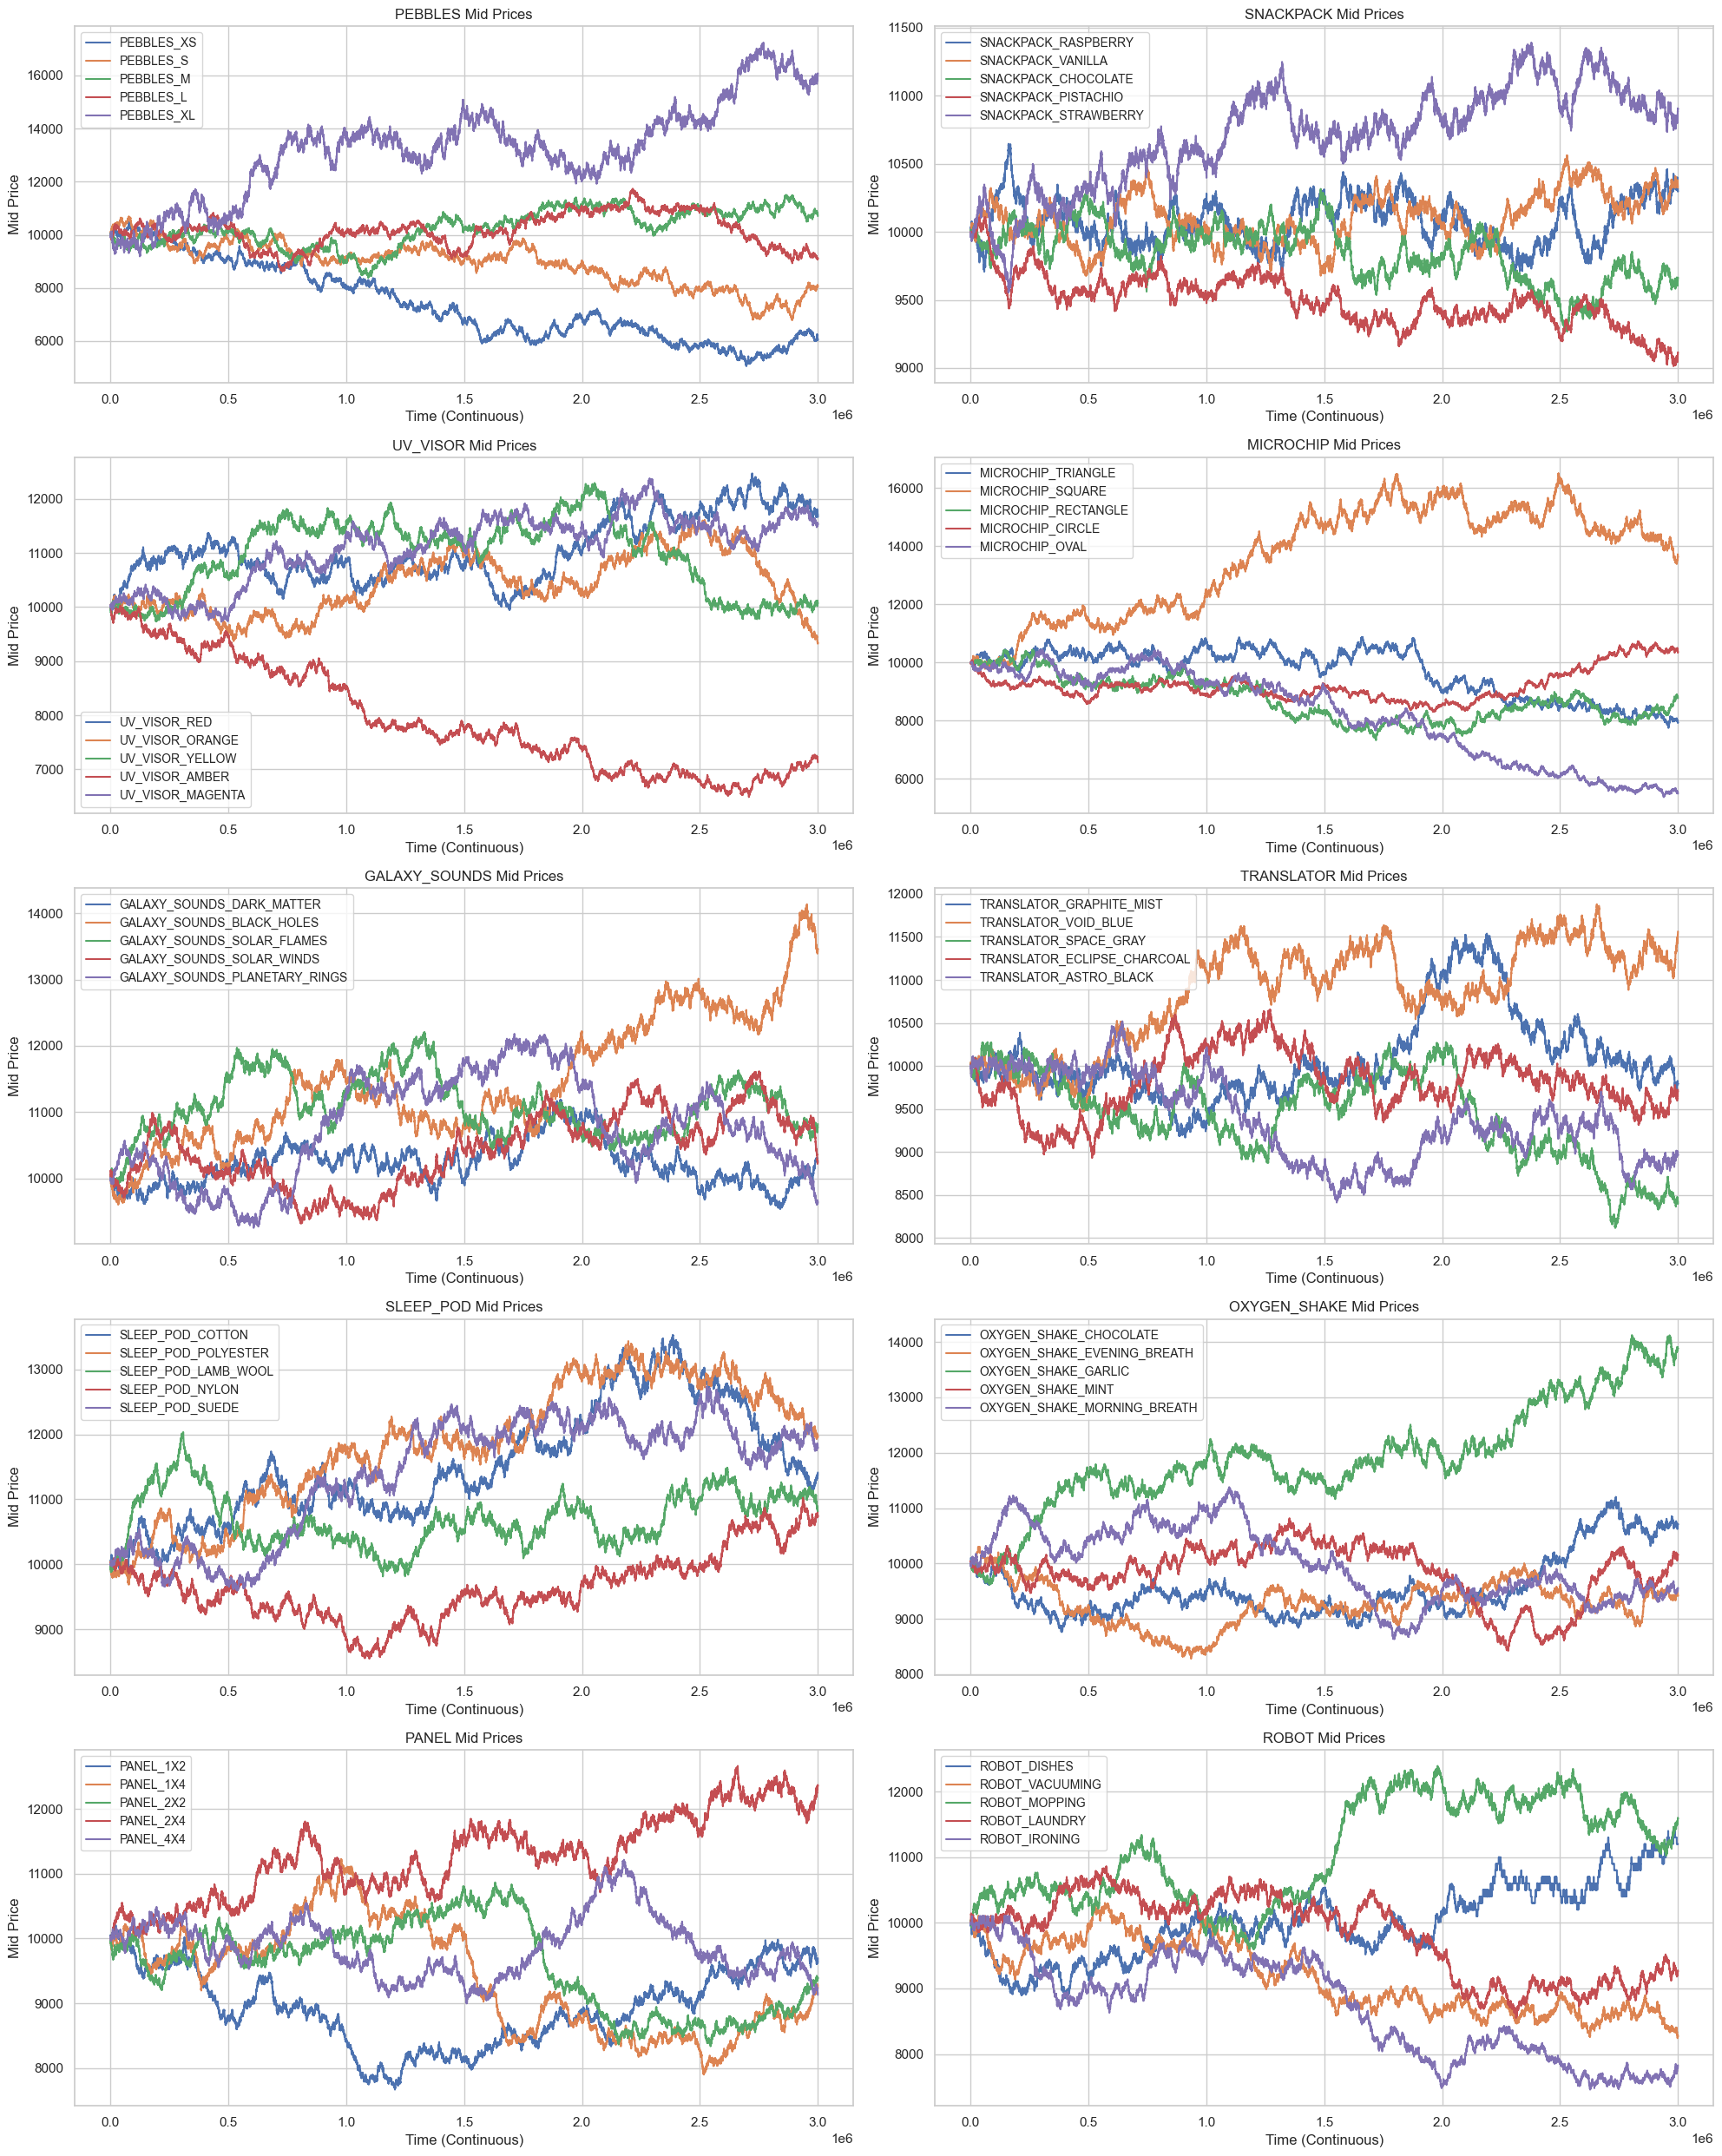

In [2]:
import pandas as pd
import glob

price_files = ['prices_round_5_day_2.csv', 'prices_round_5_day_3.csv', 'prices_round_5_day_4.csv']
dfs = []
for f in price_files:
    df = pd.read_csv(f, sep=';')
    dfs.append(df)

df_prices = pd.concat(dfs, ignore_index=True)
print("Products:", df_prices['product'].unique())
print("Number of products:", df_prices['product'].nunique())

import pandas as pd
import matplotlib.pyplot as plt


price_files = ['prices_round_5_day_2.csv', 'prices_round_5_day_3.csv', 'prices_round_5_day_4.csv']
dfs = []
for f in price_files:
    df = pd.read_csv(f, sep=';')
    # Combine day and timestamp into a continuous time axis. Timestamp goes up to 999900 per day.
    # We can just add (day - 2) * 1000000 to the timestamp to make it continuous.
    df['time_continuous'] = (df['day'] - 2) * 1000000 + df['timestamp']
    dfs.append(df)

df_prices = pd.concat(dfs, ignore_index=True)

groups = {
    'PEBBLES': ['PEBBLES_XS', 'PEBBLES_S', 'PEBBLES_M', 'PEBBLES_L', 'PEBBLES_XL'],
    'SNACKPACK': [p for p in df_prices['product'].unique() if 'SNACKPACK' in p],
    'UV_VISOR': [p for p in df_prices['product'].unique() if 'UV_VISOR' in p],
    'MICROCHIP': [p for p in df_prices['product'].unique() if 'MICROCHIP' in p],
    'GALAXY_SOUNDS': [p for p in df_prices['product'].unique() if 'GALAXY_SOUNDS' in p],
    'TRANSLATOR': [p for p in df_prices['product'].unique() if 'TRANSLATOR' in p],
    'SLEEP_POD': [p for p in df_prices['product'].unique() if 'SLEEP_POD' in p],
    'OXYGEN_SHAKE': [p for p in df_prices['product'].unique() if 'OXYGEN_SHAKE' in p],
    'PANEL': [p for p in df_prices['product'].unique() if 'PANEL' in p],
    'ROBOT': [p for p in df_prices['product'].unique() if 'ROBOT' in p]
}

fig, axes = plt.subplots(5, 2, figsize=(20, 25))
axes = axes.flatten()

for i, (group_name, products) in enumerate(groups.items()):
    ax = axes[i]
    for product in products:
        prod_data = df_prices[df_prices['product'] == product]
        ax.plot(prod_data['time_continuous'], prod_data['mid_price'], label=product)
    
    ax.set_title(f"{group_name} Mid Prices")
    ax.set_xlabel("Time (Continuous)")
    ax.set_ylabel("Mid Price")
    ax.legend(loc='best', fontsize='small')
    ax.grid(True)

plt.tight_layout()
plt.savefig("assets_visualization.png")

In [6]:
import pandas as pd

def get_category(product_name):
    if product_name.startswith("GALAXY_SOUNDS_"):
        return "GALAXY_SOUNDS"
    elif product_name.startswith("MICROCHIP_"):
        return "MICROCHIP"
    elif product_name.startswith("OXYGEN_SHAKE_"):
        return "OXYGEN_SHAKE"
    elif product_name.startswith("PANEL_"):
        return "PANEL"
    elif product_name.startswith("PEBBLES_"):
        return "PEBBLES"
    elif product_name.startswith("ROBOT_"):
        return "ROBOT"
    elif product_name.startswith("SLEEP_POD_"):
        return "SLEEP_POD"
    elif product_name.startswith("SNACKPACK_"):
        return "SNACKPACK"
    elif product_name.startswith("TRANSLATOR_"):
        return "TRANSLATOR"
    elif product_name.startswith("UV_VISOR_"):
        return "UV_VISOR"
    else:
        return None


def calculate_same_category_correlations_combined():
    print("Loading datasets...")
    p2 = pd.read_csv("prices_round_5_day_2.csv", sep=";")
    p3 = pd.read_csv("prices_round_5_day_3.csv", sep=";")
    p4 = pd.read_csv("prices_round_5_day_4.csv", sep=";")

    p2["day"] = 2
    p3["day"] = 3
    p4["day"] = 4

    prices = pd.concat([p2, p3, p4], ignore_index=True)
    prices["global_time"] = prices["day"] * 1_000_000 + prices["timestamp"]

    pivot_prices = prices.pivot_table(
        index="global_time",
        columns="product",
        values="mid_price",
        aggfunc="mean"
    )

    corr_matrix = pivot_prices.corr()

    pairs = []
    cols = corr_matrix.columns

    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            product_a = cols[i]
            product_b = cols[j]

            category_a = get_category(product_a)
            category_b = get_category(product_b)

            if category_a is None or category_b is None:
                continue

            if category_a == category_b:
                pairs.append((
                    product_a,
                    product_b,
                    category_a,
                    corr_matrix.iloc[i, j]
                ))

    pairs_df = pd.DataFrame(
        pairs,
        columns=["Product A", "Product B", "Category", "Correlation"]
    )

    pairs_df["Abs_Corr"] = pairs_df["Correlation"].abs()
    pairs_df = pairs_df.sort_values(by="Abs_Corr", ascending=False).drop(columns=["Abs_Corr"])

    print("\n--- SAME-CATEGORY CORRELATIONS ACROSS ALL 3 DAYS COMBINED ---")
    print(pairs_df.to_string(index=False))


if __name__ == "__main__":
    calculate_same_category_correlations_combined()

Loading datasets...

--- SAME-CATEGORY CORRELATIONS ACROSS ALL 3 DAYS COMBINED ---
                    Product A                     Product B      Category  Correlation
          SNACKPACK_CHOCOLATE             SNACKPACK_VANILLA     SNACKPACK    -0.925873
          MICROCHIP_RECTANGLE              MICROCHIP_SQUARE     MICROCHIP    -0.882298
             SLEEP_POD_COTTON           SLEEP_POD_POLYESTER     SLEEP_POD     0.875237
               MICROCHIP_OVAL            MICROCHIP_TRIANGLE     MICROCHIP     0.870459
               UV_VISOR_AMBER              UV_VISOR_MAGENTA      UV_VISOR    -0.867276
          SLEEP_POD_POLYESTER               SLEEP_POD_SUEDE     SLEEP_POD     0.859617
                    PEBBLES_S                    PEBBLES_XL       PEBBLES    -0.834357
                   PEBBLES_XL                    PEBBLES_XS       PEBBLES    -0.827570
                ROBOT_IRONING                 ROBOT_MOPPING         ROBOT    -0.815181
                    PEBBLES_S                  

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

def load_data():
    days = [2, 3, 4]
    prices_list, trades_list = [], []
    
    for d in days:
        p_df = pd.read_csv(f'prices_round_5_day_{d}.csv', sep=';')
        
        # Try loading with semicolon first
        t_df = pd.read_csv(f'trades_round_5_day_{d}.csv', sep=';')
        # If it read the whole row as one giant column, fallback to comma
        if 'symbol' not in t_df.columns and len(t_df.columns) == 1:
            t_df = pd.read_csv(f'trades_round_5_day_{d}.csv', sep=',')
            
        p_df['day'] = d
        t_df['day'] = d
        prices_list.append(p_df)
        trades_list.append(t_df)
        
    prices = pd.concat(prices_list, ignore_index=True)
    trades = pd.concat(trades_list, ignore_index=True)
    return prices, trades

# --- 2. Map Families ---
def get_family(product_name):
    families = ['GALAXY_SOUNDS', 'SLEEP_POD', 'ROBOT', 'UV_VISOR', 
                'TRANSLATOR', 'PANEL', 'OXYGEN_SHAKE', 'SNACKPACK', 'PEBBLES']
    for f in families:
        if product_name.startswith(f):
            return f
    return 'OTHER'

# --- 3. Reconstruct Order Flow ---
def process_order_flow(prices, trades):
    # 1. Fix the column naming mismatch between trades (symbol) and prices (product)
    if 'symbol' in trades.columns:
        trades = trades.rename(columns={'symbol': 'product'})
    elif 'Symbol' in trades.columns:  # Just in case of capitalization
        trades = trades.rename(columns={'Symbol': 'product'})
        
    # 2. Get best bid/ask per product per timestamp
    quotes = prices[['day', 'timestamp', 'product', 'bid_price_1', 'ask_price_1', 'mid_price']].copy()
    quotes.rename(columns={'bid_price_1': 'best_bid', 'ask_price_1': 'best_ask'}, inplace=True)
    
    # 3. Merge trades with quotes
    flow = pd.merge(trades, quotes, on=['day', 'timestamp', 'product'], how='left')
    
    # 4. Infer trade direction (Lee-Ready approximate)
    conditions = [
        (flow['price'] >= flow['best_ask']),
        (flow['price'] <= flow['best_bid'])
    ]
    choices = [1, -1]
    
    # Default to 0 (neutral) if inside spread
    flow['direction'] = np.select(conditions, choices, default=0) 
    flow['signed_qty'] = flow['direction'] * flow['quantity']
    flow['family'] = flow['product'].apply(get_family)
    
    return flow, quotes

# --- 4. Aggregate Flow ---
def aggregate_flow(flow):
    # Sum signed quantities by day, timestamp, and family
    family_flow = flow.groupby(['day', 'timestamp', 'family'])['signed_qty'].sum().reset_index()
    
    # Pivot to get families as columns
    ff_pivot = family_flow.pivot(index=['day', 'timestamp'], columns='family', values='signed_qty').fillna(0)
    
    # Isolate our target 8 families (excluding PEBBLES for the main block index, or include as needed)
    target_fams = ['GALAXY_SOUNDS', 'SLEEP_POD', 'ROBOT', 'UV_VISOR', 
                   'TRANSLATOR', 'PANEL', 'OXYGEN_SHAKE', 'SNACKPACK']
    
    ff_target = ff_pivot[target_fams].copy()
    ff_target['block_flow'] = ff_target.sum(axis=1)
    
    return ff_pivot, ff_target

# --- 6. Visualizations ---
def plot_visuals(ff_pivot, ff_target, flow):
    sns.set_theme(style="whitegrid")
    
    # A. Heatmap of raw correlations
    plt.figure(figsize=(10, 8))
    sns.heatmap(ff_pivot.corr(), annot=True, cmap='coolwarm', center=0, fmt=".2f")
    plt.title('Family Order-Flow Correlation')
    plt.tight_layout()
    plt.savefig('flow_correlation.png', dpi=300)
    plt.close()

    # B. Stacked event plot (Synchronized firing)
    # Count how many families have non-zero flow per timestamp
    active_families = (ff_target.drop(columns=['block_flow']) != 0).sum(axis=1)
    plt.figure(figsize=(12, 4))
    active_families.value_counts().sort_index().plot(kind='bar', color='steelblue')
    plt.title('Frequency of Multi-Family Synchronization (Sweep Size)')
    plt.xlabel('Number of Families with Simultaneous Flow')
    plt.ylabel('Count of Timestamps')
    plt.tight_layout()
    plt.savefig('sweep_sync_histogram.png', dpi=300)
    plt.close()
    
    # C. Block size distribution
    plt.figure(figsize=(10, 5))
    sns.histplot(flow[flow['signed_qty']!=0]['signed_qty'], bins=50, kde=False)
    plt.title('Distribution of Signed Trade Quantities (Block Sizes)')
    plt.xlabel('Signed Quantity')
    plt.tight_layout()
    plt.savefig('block_size_hist.png', dpi=300)
    plt.close()

def main():
    print("Loading data...")
    prices, trades = load_data()
    
    print("Processing order flow...")
    flow, quotes = process_order_flow(prices, trades)
    
    print("Aggregating signals...")
    ff_pivot, ff_target = aggregate_flow(flow)
    
    print("Generating visualizations...")
    plot_visuals(ff_pivot, ff_target, flow)
    
    print("Analysis complete. Check the working directory for PNG files.")

if __name__ == "__main__":
    main()

Loading data...
Processing order flow...
Aggregating signals...
Generating visualizations...
Analysis complete. Check the working directory for PNG files.
